# Previsione dell'affidabilità creditizia per il rilascio della carta di credito

Sei stato assunto dalla Pro National Bank come data scientist, e il tuo primo incarico consiste nel realizzare un modello in grado di stimare l'affidabilità creditizia dei clienti, al fine di aiutare il team dedicato a comprendere se accettare o meno la richiesta per il rilascio della carta di credito.

## Dati forniti

Ti vengono consegnati i dati anonimizzati di clienti che hanno già ottenuto la carta di credito e ne pagano regolarmente le rate. I dati sono disponibili in un file CSV che puoi scaricare da questo indirizzo:

credit_scoring.csv

Il file credit_scoring.csv contiene le informazioni dei correntisti che hanno richiesto l’apertura di una linea di credito.

## Colonne del dataset

- ID: numero identificativo del cliente
- CODE_GENDER: sesso del cliente
- FLAGOWNCAR: indicatore del possesso di un'automobile
- FLAGOWNREALTY: indicatore del possesso di una casa
- CNT_CHILDREN: numero di figli
- AMTINCOMETOTAL: reddito annuale
- NAMEINCOMETYPE: tipo di reddito
- NAMEEDUCATIONTYPE: livello di educazione
- NAMEFAMILYSTATUS: stato civile
- NAMEHOUSINGTYPE: tipo di abitazione
- DAYS_BIRTH: numero di giorni trascorsi dalla nascita
- DAYS_EMPLOYED: numero di giorni trascorsi dalla data di assunzione (se positivo, indica il numero di giorni da quando è disoccupato)
- FLAG_MOBIL: indicatore della presenza di un numero di cellulare
- FLAGWORKPHONE: indicatore della presenza di un numero di telefono di lavoro
- FLAG_PHONE: indicatore della presenza di un numero di telefono
- FLAG_EMAIL: indicatore della presenza di un indirizzo email
- OCCUPATION_TYPE: tipo di occupazione
- CNTFAMMEMBERS: numero di familiari
- TARGET: variabile che vale 1 se il cliente ha una elevata affidabilità creditizia (pagamento costante delle rate), 0 altrimenti.

## Obiettivo

Devi realizzare un modello che preveda il target dato, ovvero la variabile TARGET che indica se il cliente ha una buona affidabilità creditizia.

## Punto bonus

Se ad un cliente viene negata la carta di credito, il team deve essere in grado di fornirgli una motivazione. Questo significa che il tuo modello deve fornire delle indicazioni facilmente interpretabili.

## Data import

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler

from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, recall_score, f1_score, accuracy_score, precision_score, roc_curve

import warnings
warnings.filterwarnings("ignore")

In [ ]:
sns.set_theme(palette = 'Set2')

In [ ]:
df = pd.read_csv(r"https://proai-datasets.s3.eu-west-3.amazonaws.com/credit_scoring.csv")
df.head()

,ID,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,DAYS_BIRTH,DAYS_EMPLOYED,FLAG_MOBIL,FLAG_WORK_PHONE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS,TARGET
0,5008804,M,Y,Y,0,424380.57,Working,Higher education,Civil marriage,Rented apartment,-11778.0,-4438.0,1.0,1.0,0.0,0.0,NaN,2.0,0
1,5008805,M,Y,Y,0,421593.52,Working,Higher education,Civil marriage,Rented apartment,-11777.0,-4459.0,1.0,1.0,0.0,0.0,NaN,2.0,0
2,5008806,M,Y,Y,0,110958.51,Working,Secondary / secondary special,Married,House / apartment,-21471.0,-1144.0,1.0,0.0,0.0,0.0,Security staff,2.0,0
3,5008808,F,N,Y,0,267497.96,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,-18489.0,-3122.0,1.0,0.0,1.0,1.0,Sales staff,1.0,1
4,5008809,F,N,Y,0,263419.09,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,-19093.0,-3070.0,1.0,0.0,1.0,1.0,Sales staff,1.0,1


## Funzioni utili

In [ ]:
def analyze_categorical_var(df, variable, target='TARGET', normalize ='columns', total=False):
    ''' Visualize tables of contingencies of a categorical variable with the target variable.
    '''
    ct_var = pd.crosstab(df[target], df[variable], normalize=normalize)
    ct_var.columns= ct_var.columns.astype(str)
    ct_var.columns = pd.MultiIndex.from_product([[variable], ct_var.columns])

    if total:
        table = pd.DataFrame(df[variable].value_counts(normalize=True)).rename(columns={'proportion': 'percentage'}).T
        table.columns= table.columns.astype(str)
        table.columns = pd.MultiIndex.from_product([[variable], table.columns])

        return table

    else:
        return ct_var


def formatting_macro_table(macro_table, format_decimals="{:.1f}"):
    ''' Function to format a table for better appearance'''
    return (macro_table*100).style.format(format_decimals).set_table_styles(
        [{'selector': 'th.col_heading', 'props': [('text-align', 'center')]}]
    ).set_properties(**{'text-align': 'center'})


def cv_analysis(model, X, y, var_to_scale: list, proba=False):
    '''Performing cross-validation of a specified model'''
    kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_SEED)

    train_acc = []
    test_acc = []
    train_recall = []
    test_recall = []
    train_prec = []
    test_prec = []

    cv_proba = []
    y_test_cv_list = []

    for train_index, test_index in kf.split(X, y):

        x_train_cv, x_test_cv = X.iloc[train_index], X.iloc[test_index]
        y_train_cv, y_test_cv = y.iloc[train_index], y.iloc[test_index]

        #defining variables to scale
        var_to_scale_cv = var_to_scale

        #splitting in numeric and categorical variables
        train_cv_num = x_train_cv[var_to_scale_cv]
        train_cv_cat = x_train_cv.drop(columns=var_to_scale_cv)

        test_cv_num = x_test_cv[var_to_scale_cv]
        test_cv_cat = x_test_cv.drop(columns=var_to_scale_cv)

        #scaling numeric variables
        ss = StandardScaler()
        train_cv_num_scaled = pd.DataFrame(ss.fit_transform(train_cv_num), columns=var_to_scale_cv, index= x_train_cv.index)
        test_cv_num_scaled = pd.DataFrame(ss.transform(test_cv_num), columns=var_to_scale_cv, index=x_test_cv.index)

        #concat the dataframes
        x_train_cv_scaled = pd.concat([train_cv_num_scaled, train_cv_cat], axis=1)
        x_test_cv_scaled = pd.concat([test_cv_num_scaled, test_cv_cat], axis=1)

        #reordering the columns
        x_train_cv_scaled = x_train_cv_scaled[x_train_cv.columns]
        x_test_cv_scaled = x_test_cv_scaled[x_test_cv.columns]

        #fitting the models
        mod = model
        mod.fit(x_train_cv_scaled, y_train_cv)

        #calculating the metrics for train and test sets
        acc_train_lr = accuracy_score(y_train_cv, mod.predict(x_train_cv_scaled))
        acc_test_lr = accuracy_score(y_test_cv, mod.predict(x_test_cv_scaled))
        recall_train_lr = recall_score(y_train_cv, mod.predict(x_train_cv_scaled))
        recall_test_lr = recall_score(y_test_cv, mod.predict(x_test_cv_scaled))
        prec_train_lr = precision_score(y_train_cv, mod.predict(x_train_cv_scaled))
        prec_test_lr = precision_score(y_test_cv, mod.predict(x_test_cv_scaled))

        cv_proba.append(mod.predict_proba(x_test_cv_scaled)[:, 1])
        y_test_cv_list.append(y_test_cv)


        train_acc.append(acc_train_lr)
        test_acc.append(acc_test_lr)
        train_recall.append(recall_train_lr)
        test_recall.append(recall_test_lr)
        train_prec.append(prec_train_lr)
        test_prec.append(prec_test_lr)

    #creating a dictionary with the cv results
    cv_results = {
        "train_accuracy":np.array(train_acc),
        "test_accuracy":np.array(test_acc),
        "train_recall": np.array(train_recall),
        "test_recall": np.array(test_recall),
        "train_precision": np.array(train_prec),
        "test_precision": np.array(test_prec)
        }

    cv_results_mean = pd.DataFrame()
    cv_results_mean['Metrica'] = ['Accuracy', 'Recall', 'Precision']
    cv_results_mean['Train_cv_results'] = [cv_results['train_accuracy'].mean(), cv_results['train_recall'].mean(), cv_results['train_precision'].mean()]
    cv_results_mean['Test_cv_results'] = [cv_results['test_accuracy'].mean(), cv_results['test_recall'].mean(), cv_results['test_precision'].mean()]
    cv_results_mean = round(cv_results_mean, 4)

    if proba:
        return cv_results, cv_results_mean, cv_proba, y_test_cv_list
    else:
        return cv_results, cv_results_mean



def plot_confusion_matrix(y_true, y_pred, labels=["Negative", "Positive"]):
  '''
  Plot the confusion matrix for the given true and predicted labels.
  '''

  cm = confusion_matrix(y_true, y_pred) # tn, fp, fn, tp

  df_cm = pd.DataFrame(cm, index = labels,
                    columns = ["Predicted "+labels[0],"Predicted "+labels[1]])
  sns.heatmap(df_cm, annot=True, fmt='g')

# Analisi del dataset e preprocessing

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 338427 entries, 0 to 338426
Data columns (total 19 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   ID                   338427 non-null  int64  
 1   CODE_GENDER          338427 non-null  object 
 2   FLAG_OWN_CAR         338427 non-null  object 
 3   FLAG_OWN_REALTY      338427 non-null  object 
 4   CNT_CHILDREN         338427 non-null  int64  
 5   AMT_INCOME_TOTAL     338427 non-null  float64
 6   NAME_INCOME_TYPE     338427 non-null  object 
 7   NAME_EDUCATION_TYPE  338427 non-null  object 
 8   NAME_FAMILY_STATUS   338426 non-null  object 
 9   NAME_HOUSING_TYPE    338426 non-null  object 
 10  DAYS_BIRTH           338426 non-null  float64
 11  DAYS_EMPLOYED        338426 non-null  float64
 12  FLAG_MOBIL           338426 non-null  float64
 13  FLAG_WORK_PHONE      338426 non-null  float64
 14  FLAG_PHONE           338426 non-null  float64
 15  FLAG_EMAIL       

Alcune variabili categoriche, avendo valori di 0 e 1, sono state classificate erroneamente come numeriche. Le convertiamo nel tipo "object".

In [ ]:
cat_to_convert = ["FLAG_MOBIL", "FLAG_WORK_PHONE", "FLAG_PHONE", "FLAG_EMAIL", "TARGET"]

for el in cat_to_convert:
    df[el] = df[el].astype("object")


df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 338427 entries, 0 to 338426
Data columns (total 19 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   ID                   338427 non-null  int64  
 1   CODE_GENDER          338427 non-null  object 
 2   FLAG_OWN_CAR         338427 non-null  object 
 3   FLAG_OWN_REALTY      338427 non-null  object 
 4   CNT_CHILDREN         338427 non-null  int64  
 5   AMT_INCOME_TOTAL     338427 non-null  float64
 6   NAME_INCOME_TYPE     338427 non-null  object 
 7   NAME_EDUCATION_TYPE  338427 non-null  object 
 8   NAME_FAMILY_STATUS   338426 non-null  object 
 9   NAME_HOUSING_TYPE    338426 non-null  object 
 10  DAYS_BIRTH           338426 non-null  float64
 11  DAYS_EMPLOYED        338426 non-null  float64
 12  FLAG_MOBIL           338426 non-null  object 
 13  FLAG_WORK_PHONE      338426 non-null  object 
 14  FLAG_PHONE           338426 non-null  object 
 15  FLAG_EMAIL       

Rimuoviamo inoltre la variabile ID che non è informativa allo scopo del modello

In [ ]:
df = df.drop("ID", axis=1)
df.shape

(338427, 18)

## Gestione dati mancanti

Si osserva se sono presenti valori mancanti.

In [ ]:
df.isna().sum()

,0
CODE_GENDER,0
FLAG_OWN_CAR,0
FLAG_OWN_REALTY,0
CNT_CHILDREN,0
AMT_INCOME_TOTAL,0
NAME_INCOME_TYPE,0
NAME_EDUCATION_TYPE,0
NAME_FAMILY_STATUS,1
NAME_HOUSING_TYPE,1
DAYS_BIRTH,1


In [ ]:
df.iloc[-1, :]

,338426
CODE_GENDER,F
FLAG_OWN_CAR,N
FLAG_OWN_REALTY,N
CNT_CHILDREN,0
AMT_INCOME_TOTAL,68765.48
NAME_INCOME_TYPE,Working
NAME_EDUCATION_TYPE,Secondary / se
NAME_FAMILY_STATUS,NaN
NAME_HOUSING_TYPE,NaN
DAYS_BIRTH,NaN


Si osserva che l'ultima riga del dataset riporta praticamente tutti valori NA per le variabili, quindi si decide di rimuovere questa riga dal dataset

In [ ]:
df = df.iloc[:-1, :]

In [ ]:
df.isna().sum()

,0
CODE_GENDER,0
FLAG_OWN_CAR,0
FLAG_OWN_REALTY,0
CNT_CHILDREN,0
AMT_INCOME_TOTAL,0
NAME_INCOME_TYPE,0
NAME_EDUCATION_TYPE,0
NAME_FAMILY_STATUS,0
NAME_HOUSING_TYPE,0
DAYS_BIRTH,0


I valori NA rimanenti risultano tutti appartenenti alla variabile OCCUPATION_TYPE

In [ ]:
df['OCCUPATION_TYPE'].value_counts()

,count
OCCUPATION_TYPE,
Laborers,60146
Core staff,33527
Sales staff,31652
Managers,27384
Drivers,20020
High skill tech staff,13399
Accountants,12281
Medicine staff,10438
Cooking staff,6248


In [ ]:
df.OCCUPATION_TYPE.isna().sum()/len(df)*100

np.float64(30.535774438134183)

Essendo i valori mancanti circa il 30% dei totali, si decide di lasciarli nel dataset e creare una nuova categoria della variabile OCCUPATION_TYPE che racchiuda i vaori mancanti, chiamata "unknown".

In [ ]:
df['OCCUPATION_TYPE'] = df['OCCUPATION_TYPE'].fillna("unknown")

In [ ]:
df['OCCUPATION_TYPE'].value_counts()

,count
OCCUPATION_TYPE,
unknown,103341
Laborers,60146
Core staff,33527
Sales staff,31652
Managers,27384
Drivers,20020
High skill tech staff,13399
Accountants,12281
Medicine staff,10438


## Variabile target

Si analizzano ora i conteggi della variabile target.

TARGET
0    91.2
1     8.8
Name: count, dtype: float64


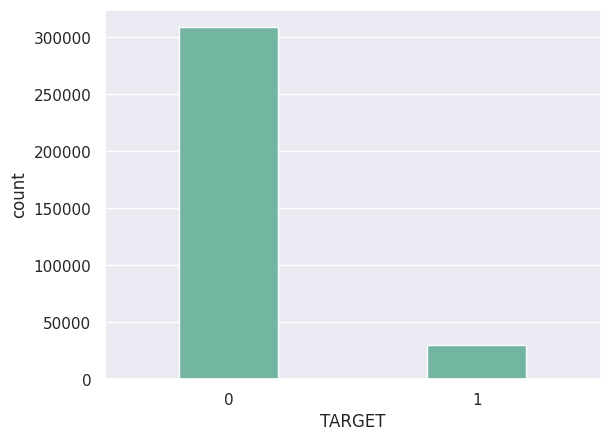

In [ ]:
print(round(df['TARGET'].value_counts()/len(df)*100, 1))
sns.countplot(x = df['TARGET'], width = 0.4)
plt.show()

Si osserva che la variabile target è molto sbilanciata, con il 91% dei dati appartenenti alla classe 0 e il 9% alla classe 1.

## Variabili quantitative

Viene creata la variabile AGE convertendo DAYS_BIRTH in anni, così che sia maggiormente interpretabile.

In [ ]:
df['AGE'] = round(abs(df["DAYS_BIRTH"])/365.25, 0)

Si osservano quindi le statistiche delle variabili numeriche

In [ ]:
numeric_df = df.select_dtypes(include=['number'])
numeric_df.describe()

,CNT_CHILDREN,AMT_INCOME_TOTAL,DAYS_BIRTH,DAYS_EMPLOYED,CNT_FAM_MEMBERS,AGE
count,338426.000000,3.384260e+05,338426.000000,338426.000000,338426.000000,338426.000000
mean,0.428936,1.876689e+05,-15998.212897,60234.533869,2.197228,43.800178
std,0.727991,1.107863e+05,4193.088539,138522.923248,0.899570,11.483992
min,0.000000,2.554898e+04,-26636.000000,-17973.000000,1.000000,21.000000
25%,0.000000,1.212306e+05,-19467.000000,-3116.000000,2.000000,34.000000
50%,0.000000,1.628556e+05,-15623.000000,-1483.000000,2.000000,43.000000
75%,1.000000,2.252082e+05,-12516.250000,-378.000000,3.000000,53.000000
max,19.000000,7.071016e+06,-7566.000000,396498.000000,20.000000,73.000000


La media del numero di figli risulta essere 0.4. Si osserva infatti che il 50% dei dati corrisponde a persone senza figli e che il 75% dei dati arriva al massimo ad averne 1. La maggioranza del dataset è dunque costituita da persone senza figli o con 1 figlio. Questo viene confermato nella tabella seguente dove viene riportato il conteggio per numero di figli presenti nel dataset e da cui si ricava che circa l'89% del dataset è costituito da persone con 0 o 1 figlio.

In [ ]:
df['CNT_CHILDREN'].value_counts().sort_values(ascending=False)

,count
CNT_CHILDREN,
0,234630
1,67922
2,31117
3,4252
4,367
5,120
12,4
9,4
6,4


In [ ]:
round((234630+67922)/len(df)*100,2)

89.4

Si osserva inoltre come il massimo nella variabile CNT_CHILDREN sia 19, che si verifica in un solo dato e che è un valore anomalo ma ancora possibile.

Per quanto riguarda le altre variabili si osserva che il reddito annuale medio è di 187000 circa, con il 75% dei dati sotto 225000 e un massimo a 7000000 ad indicare la presenza di qualche valore estremo verso l'alto. I soggetti vanno dai 20 ai 73 anni con una media di 43 e hanno un numero di familiari compreso tra 1 e 20 con una media di 2. Osserviamo inoltre che il 75% dei soggetti ha massimo 3 familiari.

In [ ]:
df['CNT_FAM_MEMBERS'].value_counts().sort_values(ascending=False)

,count
CNT_FAM_MEMBERS,
2.0,180706
1.0,64896
3.0,59148
4.0,29236
5.0,3955
6.0,356
7.0,111
14.0,4
11.0,4


Si analizza meglio la variabile DAYS_EMPLOYED, suddividendola in soggetti impiegati (valori negativi della variabile) e soggetti disoccupati (valori positivi) e convertendo i valori dei giorni in anni per maggiore interpretabilità.

In [ ]:
df_employed = df[df['DAYS_EMPLOYED'] <= 0]
(abs(df_employed['DAYS_EMPLOYED'])/365.25).describe()

,DAYS_EMPLOYED
count,280585.000000
mean,7.217389
std,6.601648
min,0.032854
25%,2.524298
50%,5.327858
75%,9.642710
max,49.207392


I soggetti impiegati lo sono in media da 7 anni e con un massimo di 49.

count    57841.000000
mean       999.913457
std         20.064483
min        915.438741
25%        986.422998
50%        999.956194
75%       1013.549624
max       1085.552361
Name: DAYS_EMPLOYED, dtype: float64


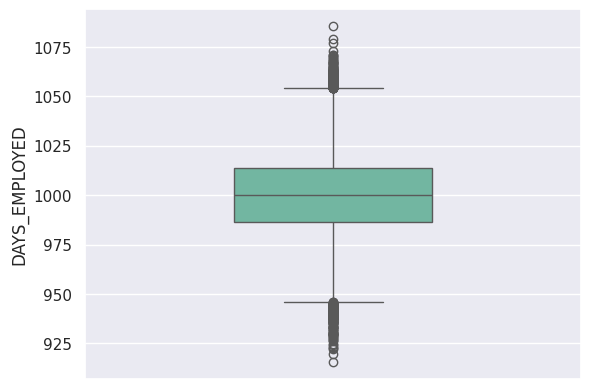

In [ ]:
df_unemployed = df[df['DAYS_EMPLOYED'] >= 0]
print((df_unemployed['DAYS_EMPLOYED']/365.25).describe())
sns.boxplot(df_unemployed['DAYS_EMPLOYED']/365.25, width= 0.4);

I valori dei soggetti disoccupati sono anomali, vanno da 915 a 1085 anni, cosa non possibile.  
Per questo motivo si decide di creare una variabile dummy per i disoccupati con valore 0 per gli impiegati e 1 per i disoccupati, mentre si mantiene la variabile days_employed per gli occupati, andando a sostituire i valori positivi, corrispondenti ai disoccupati, con il valore 0.

In [ ]:
df['YEARS_EMPLOYED'] = df['DAYS_EMPLOYED'].apply(lambda x: abs(x)/365.25 if x <= 0 else 0)

df['FLAG_UNEMPLOYED'] = df['DAYS_EMPLOYED'].apply(lambda x: 0 if x <= 0 else 1)
df['FLAG_UNEMPLOYED'] = df['FLAG_UNEMPLOYED'].astype('object')

df.head()

,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,DAYS_BIRTH,...,FLAG_MOBIL,FLAG_WORK_PHONE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS,TARGET,AGE,YEARS_EMPLOYED,FLAG_UNEMPLOYED
0,M,Y,Y,0,424380.57,Working,Higher education,Civil marriage,Rented apartment,-11778.0,...,1.0,1.0,0.0,0.0,unknown,2.0,0,32.0,12.150582,0
1,M,Y,Y,0,421593.52,Working,Higher education,Civil marriage,Rented apartment,-11777.0,...,1.0,1.0,0.0,0.0,unknown,2.0,0,32.0,12.208077,0
2,M,Y,Y,0,110958.51,Working,Secondary / secondary special,Married,House / apartment,-21471.0,...,1.0,0.0,0.0,0.0,Security staff,2.0,0,59.0,3.132101,0
3,F,N,Y,0,267497.96,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,-18489.0,...,1.0,0.0,1.0,1.0,Sales staff,1.0,1,51.0,8.547570,0
4,F,N,Y,0,263419.09,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,-19093.0,...,1.0,0.0,1.0,1.0,Sales staff,1.0,1,52.0,8.405202,0


Si visualizzano nuovamente le statistiche delle variabili numeriche

In [ ]:
numeric_df = df.select_dtypes(include=['number'])
numeric_df.describe()

,CNT_CHILDREN,AMT_INCOME_TOTAL,DAYS_BIRTH,DAYS_EMPLOYED,CNT_FAM_MEMBERS,AGE,YEARS_EMPLOYED
count,338426.000000,3.384260e+05,338426.000000,338426.000000,338426.000000,338426.000000,338426.000000
mean,0.428936,1.876689e+05,-15998.212897,60234.533869,2.197228,43.800178,5.983852
std,0.727991,1.107863e+05,4193.088539,138522.923248,0.899570,11.483992,6.596546
min,0.000000,2.554898e+04,-26636.000000,-17973.000000,1.000000,21.000000,0.000000
25%,0.000000,1.212306e+05,-19467.000000,-3116.000000,2.000000,34.000000,1.034908
50%,0.000000,1.628556e+05,-15623.000000,-1483.000000,2.000000,43.000000,4.060233
75%,1.000000,2.252082e+05,-12516.250000,-378.000000,3.000000,53.000000,8.531143
max,19.000000,7.071016e+06,-7566.000000,396498.000000,20.000000,73.000000,49.207392


Si osserva ora che, avendo inserito gli 0, le statistiche della variabile YEARS_EMPLOYED si sono leggermente abbassate, tuttavia l'inserimento è coerente con il significato della variabile.

Viene ora generato il nuovo dataset con le variabile che verranno utilizzate per i modelli, quindi eliminando DAYS_BIRTH e DAYS_EMPLOYED

In [ ]:
df = df.drop(['DAYS_BIRTH', 'DAYS_EMPLOYED'], axis=1)

In [ ]:
df.head()

,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,FLAG_MOBIL,FLAG_WORK_PHONE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS,TARGET,AGE,YEARS_EMPLOYED,FLAG_UNEMPLOYED
0,M,Y,Y,0,424380.57,Working,Higher education,Civil marriage,Rented apartment,1.0,1.0,0.0,0.0,unknown,2.0,0,32.0,12.150582,0
1,M,Y,Y,0,421593.52,Working,Higher education,Civil marriage,Rented apartment,1.0,1.0,0.0,0.0,unknown,2.0,0,32.0,12.208077,0
2,M,Y,Y,0,110958.51,Working,Secondary / secondary special,Married,House / apartment,1.0,0.0,0.0,0.0,Security staff,2.0,0,59.0,3.132101,0
3,F,N,Y,0,267497.96,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,1.0,0.0,1.0,1.0,Sales staff,1.0,1,51.0,8.547570,0
4,F,N,Y,0,263419.09,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,1.0,0.0,1.0,1.0,Sales staff,1.0,1,52.0,8.405202,0


Le variabili quantitative sono dunque:

- CNT_CHILDREN
- AMT_INCOME_TOTAL
- CNT_FAM_MEMBERS
- AGE
- YEARS_EMPLOYED

In [ ]:
numeric_df = df.select_dtypes(include=['number'])
numeric_df.head()

,CNT_CHILDREN,AMT_INCOME_TOTAL,CNT_FAM_MEMBERS,AGE,YEARS_EMPLOYED
0,0,424380.57,2.0,32.0,12.150582
1,0,421593.52,2.0,32.0,12.208077
2,0,110958.51,2.0,59.0,3.132101
3,0,267497.96,1.0,51.0,8.547570
4,0,263419.09,1.0,52.0,8.405202


Si osservano le distribuzioni di queste variabili mediante i boxplot

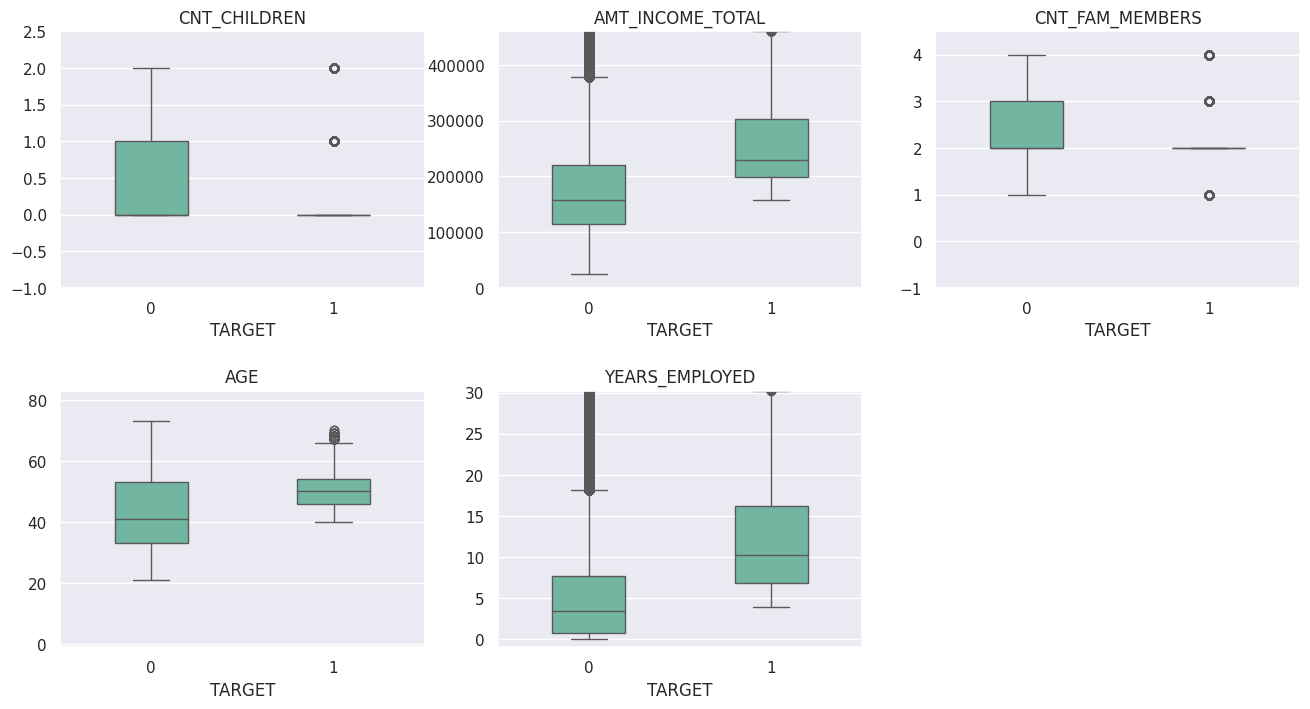

In [ ]:
plt.figure(figsize=(16,8))
plt.subplots_adjust(hspace=0.4)
for i,var in enumerate(numeric_df):
    plt.subplot(2,3,i+1)
    sns.boxplot(x = df['TARGET'], y=df[var], width=0.4)

    var_0 = df[df['TARGET'] == 0][var]
    var_1 = df[df['TARGET'] == 1][var]

    Q1_0 = np.percentile(var_0, 25)
    Q3_0 = np.percentile(var_0, 75)
    IQR_0 = Q3_0 - Q1_0

    Q1_1 = np.percentile(var_1, 25)
    Q3_1 = np.percentile(var_1, 75)
    IQR_1 = Q3_1 - Q1_1

    ylim_candidate_0 = Q3_0 +1.5*IQR_0
    ylim_candidate_1 = Q3_1 + 1.5*IQR_1

    plt.ylim(-1, max(ylim_candidate_0, ylim_candidate_1))
    plt.title(var)
    plt.ylabel(None)
    plt.xlabel('TARGET')



Si osserva che il reddito annuale è maggiore per la classe 1, ovvero quella con maggiore affidabilità creditizia, così come gli appartenenti a questa classe sono impiegati mediamente da più anni e quindi potenzialmente hanno maggiore stabilità economica.  
Si osserva inoltre che la distribuzione delle età della classe 0 è maggiormente dispersa rispetto a quella della classe 1.

Osserviamo meglio le variabili CNT_FAM_MEMBERS e CNT_CHILDREN con i seguenti barplot

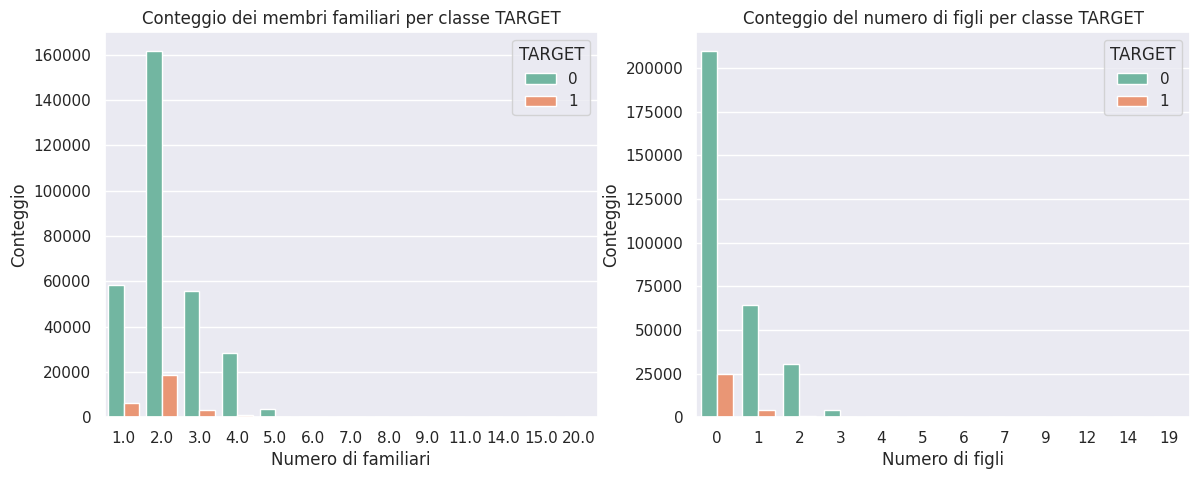

In [ ]:
plt.figure(figsize=(14,5))

plt.subplot(1,2,1)
sns.countplot(data=df, x='CNT_FAM_MEMBERS', hue='TARGET')
plt.title('Conteggio dei membri familiari per classe TARGET')
plt.xlabel('Numero di familiari')
plt.ylabel('Conteggio')
plt.legend(title='TARGET')

plt.subplot(1,2,2)
sns.countplot(data=df, x='CNT_CHILDREN', hue='TARGET')
plt.title('Conteggio del numero di figli per classe TARGET')
plt.xlabel('Numero di figli')
plt.ylabel('Conteggio')
plt.legend(title='TARGET')


plt.show()

Si osserva che il numero dei familiari dei soggetti è concentrato principalmente sul 2 e il numero di figli sullo 0.   
Per entrambe le variabili la classe 1, essendo molto più popolata, ha un conteggio più elevato.

## Variabili categoriche

Si analizzano ora le variabili categoriche

In [ ]:
categorical_df = df.select_dtypes(include=['object'])

### Categoriche binarie

Nella seguente tabella si osserva la distribuzione del target rispetto alle categorie delle variabili categoriche binarie, sottoforma di percentuali.

In [ ]:
binary_categorical_var = ['CODE_GENDER', 'FLAG_OWN_CAR', 'FLAG_OWN_REALTY', 'FLAG_MOBIL', 'FLAG_WORK_PHONE', 'FLAG_PHONE', 'FLAG_EMAIL', 'FLAG_UNEMPLOYED']

ct_vars = []
for var in binary_categorical_var:
    ct_vars.append(analyze_categorical_var(df, var, normalize='columns'))

macro_table = pd.concat(ct_vars, axis=1)

formatting_macro_table(macro_table)

Si può osservare come la distribuzione delle categorie rispetto alla classe target rispecchi la distribuzione di quest'ultima, ovvero tutte le variabili presentano circa il 90% dei soggetti appartenenti alla classe 0 e circa il 10% appartenenti alla classe 1, ad eccezione della variabile FLAG_UNEMPLOYED che mostra come il 100% dei disoccupati non abbia affidabilità creditizia.

Si osserva ora come si distribuiscono le categorie delle variabili per singola classe del target.

In [ ]:
ct_vars = []
for var in binary_categorical_var:
    ct_vars.append(analyze_categorical_var(df, var, normalize='index'))

macro_table = pd.concat(ct_vars, axis=1)

formatting_macro_table(macro_table)

Si può osservare come la distribuzione delle categorie sia molto simile tra la classe 0 e la classe 1, ad esempio per entrambe le classi è presente circa il 66% di donne e il 33% di uomini.  
Per quanto riguarda la variabile FLAG_UNEMPLOYED, si osserva come la classe 1, ovvero quella con affidabilità creditizia, sia composta per il 100% da impiegati (categoria 0), mentre la classe 0 è composta da un 80% di impiegati e 20% disoccupati.

Si può inoltre osservare come il 100% dei soggetti possegga un numero di cellulare. Per questo motivo, non essendo significativa ai fini di un modello predittivo, questa variabile verrà eliminata dal dataset.

Si può inoltre osservare, nella tabella seguente, come le distribuzioni tra le categorie delle variabili rispecchino le distribuzioni totali di quelle variabili all'interno del dataset

In [ ]:
tables=[]
for var in binary_categorical_var:
    tables.append(analyze_categorical_var(df, var, normalize='columns', total=True))
macro_table = pd.concat(tables, axis=1)

formatting_macro_table(macro_table)

### Categoriche non binarie

Si analizzano ora le variabili categoriche non binarie

In [ ]:
categorical_non_binary = [x for x in categorical_df.columns if x not in binary_categorical_var]
categorical_non_binary.remove('TARGET')
categorical_non_binary

['NAME_INCOME_TYPE',
 'NAME_EDUCATION_TYPE',
 'NAME_FAMILY_STATUS',
 'NAME_HOUSING_TYPE',
 'OCCUPATION_TYPE']

#### Variabile NAME_INCOME_TYPE

In [ ]:
total = analyze_categorical_var(df, 'NAME_INCOME_TYPE', normalize='columns', total=True)
vs_target = analyze_categorical_var(df, 'NAME_INCOME_TYPE', normalize='columns')

formatting_macro_table(pd.concat([total, vs_target], axis=0), format_decimals="{:.2f}")

Dalle tabelle riportate si può osservare come il numero di studenti sia praticamente nullo rispetto al resto del dataset e come la maggior parte dei soggetti appartengano alla categoria working. Si osserva inoltre che il 100% dei pensionati sia classificato come 0 ovvero senza affidabilità creditizia.

Dato che i pensionati sono tutti appartenenti alla classe 0, non sono indicativi per eventuali relazioni con la variabile target, pertanto questa categoria verrà rimossa dal dataset, così come la categoria degli studenti che rappresenta solo lo 0.01% dei dati.  
Per le restanti tre categorie verrà effettuato un one-hot encoding.

Inoltre, come visto dall'analisi delle variabili categoriche binarie, FLAG_MOBIL è uguale per tutti i soggetti del dataset e pertanto non indicativa ai fini della costruzione di un modello. Per questo motivo anch'essa viene rimossa dal dataset.

In [ ]:
df_filtered = df[(df['NAME_INCOME_TYPE'] != 'Pensioner') & (df['NAME_INCOME_TYPE'] != 'Student')]
df_filtered = df_filtered.drop(['FLAG_MOBIL'], axis=1)


#### Variabile NAME_EDUCATION_TYPE

In [ ]:
total = analyze_categorical_var(df_filtered, 'NAME_EDUCATION_TYPE', normalize='columns', total=True)
vs_target = analyze_categorical_var(df_filtered, 'NAME_EDUCATION_TYPE', normalize='columns')

formatting_macro_table(pd.concat([total, vs_target], axis=0), format_decimals="{:.2f}")

Si può osservare come la maggior parte dei soggetti appartenga alla categoria Secondary/secondary special mentre la categoria meno frequente è academic degree.  
Per questa variabile si sceglie di fare un ordinal encoding con il seguente ordine:  
1 - Lower secondary  
2 - Secondary/secondary special  
3 - Incomplete higher  
4 - Higher education  
5 - Academic degree

#### Variabile NAME_FAMILY STATUS

In [ ]:
total = analyze_categorical_var(df_filtered, 'NAME_FAMILY_STATUS', normalize='columns', total=True)
vs_target = analyze_categorical_var(df_filtered, 'NAME_FAMILY_STATUS', normalize='columns')

formatting_macro_table(pd.concat([total, vs_target], axis=0), format_decimals="{:.2f}")

Osserviamo che il 78% del dataset è composto da persone sposate (compreso il matrimonio civile), inoltre si può osservare come rispetto al target la categoria "civil marriage" e "married" si comporti allo stesso modo, con il 90% dei dati di classe 0 e il 10% di classe 1. Queste due categorie possono quindi essere accorpate in una unica denominata "Married_tot".  
Per quanto riguarda le altre tre categorie, invece, avendo comportamenti leggermente diversi rispetto al target si decide di lasciarle separate.  
Verrà effettuato un one hot encoding.

In [ ]:
df_filtered['NAME_FAMILY_STATUS'] =df_filtered['NAME_FAMILY_STATUS'].apply(lambda x: "Married_tot" if x == 'Married' or x == 'Civil marriage' else x)

#### Variabile NAME_HOUSING_TYPE

In [ ]:
total = analyze_categorical_var(df_filtered, 'NAME_HOUSING_TYPE', normalize='columns', total=True)
vs_target = analyze_categorical_var(df_filtered, 'NAME_HOUSING_TYPE', normalize='columns')

formatting_macro_table(pd.concat([total, vs_target], axis=0), format_decimals="{:.2f}")

In questa variabile si osserva che la maggior parte dei soggetti vivono in una casa di proprietà. Inoltre si può osservare come i soggetti che vivono con i genitori abbiano una frequenza per la classe 1 (quindi affidabilità creditizia) piuttosto bassa (2%) rispetto alle altre categorie.  
Si effettua un onehot encoding.

#### Variabile OCCUPATION_TYPE

In [ ]:
total_percentage = analyze_categorical_var(df_filtered, 'OCCUPATION_TYPE', normalize='columns', total=True).T
percentage_vs_target =analyze_categorical_var(df_filtered, 'OCCUPATION_TYPE', normalize='columns').T

In [ ]:
formatting_macro_table(total_percentage.merge(percentage_vs_target, on='OCCUPATION_TYPE').rename(columns={'percentage': 'Total', 0: 'Target 0', 1: 'Target 1'}), format_decimals="{:.2f}")

,Total,Target 0,Target 1
OCCUPATION_TYPE,,,
Laborers,21.44,90.34,9.66
unknown,16.22,89.96,10.04
Core staff,11.95,90.05,9.95
Sales staff,11.28,93.51,6.49
Managers,9.76,82.14,17.86
Drivers,7.14,89.17,10.83
High skill tech staff,4.78,88.13,11.87
Accountants,4.38,86.84,13.16
Medicine staff,3.72,86.34,13.66


Per questa variabile, si decide di raggruppare le categorie con frequenza inferiore all'1% in un'unica categoria "other", escludendo da questo raggruppamento le categorie "Realty agents", "HR staff" e "Private service staff", in quanto presentano una presenza di affidabilità più elevata avendo una % di soggetti in classe 1 tra l'11% e il 15%.

In [ ]:
cat_to_exclude = ['Realty agents', 'HR staff', 'Private service staff']
freq = df_filtered['OCCUPATION_TYPE'].value_counts(normalize=True)
low_freq = freq[freq <= 0.01].index.tolist()
cat_to_group = [cat for cat in low_freq if cat not in cat_to_exclude]

In [ ]:
df_filtered['OCCUPATION_TYPE'] = df_filtered['OCCUPATION_TYPE'].apply(lambda x: 'Other' if x in cat_to_group else x)

Sulle restanti categorie viene applicato il one-hot encoding

### Features encoding

Si effettua un ordinal encoding per la variabile  NAME_EDUCATION_TYPE e un one-hot encoding per le altre variabili categoriche non binarie.  
Per le variabili binarie non codificate si effettua un label encoding.

In [ ]:
le = LabelEncoder()

#ordinal encoding
education_map = {'Lower secondary': 0, 'Secondary / secondary special': 1, 'Incomplete higher': 2, 'Higher education': 3, 'Academic degree': 4}
df_filtered['NAME_EDUCATION_TYPE'] = df_filtered['NAME_EDUCATION_TYPE'].map(education_map)

#label encoding
binary_to_codify = [cat for cat in binary_categorical_var if cat != 'FLAG_MOBIL' ]
for cat in binary_to_codify:
    df_filtered[cat] = le.fit_transform(df_filtered[cat])

#one-hot encoding
ohe_list = [x for x in categorical_non_binary if x != 'NAME_EDUCATION_TYPE']
df_filtered = pd.get_dummies(df_filtered, columns=ohe_list, drop_first=True, dtype=int)

In [ ]:
df_filtered.head()

,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,NAME_EDUCATION_TYPE,FLAG_WORK_PHONE,FLAG_PHONE,FLAG_EMAIL,CNT_FAM_MEMBERS,...,OCCUPATION_TYPE_High skill tech staff,OCCUPATION_TYPE_Laborers,OCCUPATION_TYPE_Managers,OCCUPATION_TYPE_Medicine staff,OCCUPATION_TYPE_Other,OCCUPATION_TYPE_Private service staff,OCCUPATION_TYPE_Realty agents,OCCUPATION_TYPE_Sales staff,OCCUPATION_TYPE_Security staff,OCCUPATION_TYPE_unknown
0,1,1,1,0,424380.57,3,1,0,0,2.0,...,0,0,0,0,0,0,0,0,0,1
1,1,1,1,0,421593.52,3,1,0,0,2.0,...,0,0,0,0,0,0,0,0,0,1
2,1,1,1,0,110958.51,1,0,0,0,2.0,...,0,0,0,0,0,0,0,0,1,0
3,0,0,1,0,267497.96,1,0,1,1,1.0,...,0,0,0,0,0,0,0,1,0,0
4,0,0,1,0,263419.09,1,0,1,1,1.0,...,0,0,0,0,0,0,0,1,0,0


In [ ]:
df_filtered.info()

<class 'pandas.core.frame.DataFrame'>
Index: 280568 entries, 0 to 338416
Data columns (total 39 columns):
 #   Column                                   Non-Null Count   Dtype  
---  ------                                   --------------   -----  
 0   CODE_GENDER                              280568 non-null  int64  
 1   FLAG_OWN_CAR                             280568 non-null  int64  
 2   FLAG_OWN_REALTY                          280568 non-null  int64  
 3   CNT_CHILDREN                             280568 non-null  int64  
 4   AMT_INCOME_TOTAL                         280568 non-null  float64
 5   NAME_EDUCATION_TYPE                      280568 non-null  int64  
 6   FLAG_WORK_PHONE                          280568 non-null  int64  
 7   FLAG_PHONE                               280568 non-null  int64  
 8   FLAG_EMAIL                               280568 non-null  int64  
 9   CNT_FAM_MEMBERS                          280568 non-null  float64
 10  TARGET                               

## Train-test split

Si divide il dataset in train e test set per poter costruire i successivi modelli.

In [ ]:
df_filtered['TARGET']= df_filtered['TARGET'].astype('int')

In [ ]:
RANDOM_SEED = 42

In [ ]:
X = df_filtered.drop('TARGET', axis=1)
y = df_filtered['TARGET']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=RANDOM_SEED, stratify=y)

In [ ]:
y_test.value_counts(normalize=True)

,proportion
TARGET,
0,0.894073
1,0.105927


## Standardizzazione variabili continue

Si effettua l'autoscalatura delle variabili numeriche continue

In [ ]:
ss = StandardScaler()
to_scale = ['AMT_INCOME_TOTAL', 'AGE', 'YEARS_EMPLOYED']
X_train[to_scale] = ss.fit_transform(X_train[to_scale])
X_test[to_scale] = ss.transform(X_test[to_scale])

# Costruzione dei modelli predittivi

Si è deciso di testare i seguenti modelli di classificazione:

- Regressione Logistica
- Decision Tree
- Random Forest

Tutti i modelli verranno costruiti utilizzando il parametro class_weight = 'balanced', in modo tale da ovviare al forte sbilanciamento di classe presente nel dataset.

## Regressione logistica

Si costruisce un modello di regressione logistica e si testa in cross-validation sul train set

In [ ]:
lr = LogisticRegression(random_state=RANDOM_SEED, class_weight="balanced")
cv_results_lr, cv_results_mean_lr, cv_proba_lr, y_test_cv_list_lr = cv_analysis(lr, X_train, y_train, var_to_scale=to_scale, proba=True)

In [ ]:
cv_results_lr

{'train_accuracy': array([0.80802281, 0.80837366, 0.80752716, 0.80820659, 0.80782339]),
 'test_accuracy': array([0.80866989, 0.80806843, 0.80891493, 0.80590764, 0.80795277]),
 'train_recall': array([0.84584648, 0.84716088, 0.84616193, 0.84805468, 0.84642482]),
 'test_recall': array([0.84858044, 0.84164038, 0.85131441, 0.84500526, 0.846898  ]),
 'train_precision': array([0.3377845 , 0.33840176, 0.33719542, 0.33830408, 0.33760433]),
 'test_precision': array([0.33896169, 0.33729456, 0.33962581, 0.33500083, 0.33783557])}

In [ ]:
cv_results_mean_lr

,Metrica,Train_cv_results,Test_cv_results
0,Accuracy,0.8080,0.8079
1,Recall,0.8467,0.8467
2,Precision,0.3379,0.3377


I risultati della cross-validation mostrano la validità del modello della regressione logistica, la quale non risulta affetta da overfitting, essendo i parametri calcolati sul train set praticamnete uguali a quelli calcolati sul test set.

Le performances del modello mostrano un'accuratezza dell'81%, anche la recall è abbastanza alta, dell'85%, ad indicare che l'85% dei soggetti appartenenti alla classe 1 sonos tati classificati correttamente. Tuttavia la precision è molto bassa, ad indicare la presenza di molti falsi positivi. Questo rischierebbe di identificare persone con alta affidabilità creditizia che in realtà non lo sono.

Proviamo a calcolare le classificazioni in base a soglie differenti da 0.5, utilizzando i dati della cross-validation.

In [ ]:
y_proba_cv = np.concatenate(cv_proba_lr, axis=0)
y_test_cv = np.concatenate(y_test_cv_list_lr, axis=0)

soglie = np.arange(0,1.02, 0.02)

results = []

for soglia in soglie:

    y_proba_cv_converted = np.where(y_proba_cv >= soglia, 1, 0)

    results.append({'soglia': soglia,
        'Accuracy_cv': accuracy_score(y_test_cv,y_proba_cv_converted),
        'Precision_cv': precision_score(y_test_cv,y_proba_cv_converted, zero_division=0),
        'Recall_cv': recall_score(y_test_cv,y_proba_cv_converted),
        'f1_score_cv': f1_score(y_test_cv,y_proba_cv_converted),

    })

df_results = pd.DataFrame(results)

round(df_results.sort_values('f1_score_cv', ascending=False), 6).head(20)

,soglia,Accuracy_cv,Precision_cv,Recall_cv,f1_score_cv
33,0.66,0.855218,0.395199,0.691693,0.503005
34,0.68,0.859976,0.402843,0.667424,0.502430
32,0.64,0.850241,0.387588,0.713438,0.502295
31,0.62,0.845242,0.380664,0.735310,0.501636
35,0.70,0.864133,0.409884,0.642902,0.500606
30,0.60,0.839918,0.373665,0.756130,0.500160
36,0.72,0.868271,0.417662,0.617876,0.498414
29,0.58,0.833979,0.366125,0.775815,0.497478
37,0.74,0.872348,0.426144,0.591798,0.495492
28,0.56,0.827764,0.358684,0.794490,0.494237


Si osserva che il miglior bilanciamento tra performance di accuracy, recall e precision è con la soglia a 0.66 in cui la precision sale da 0.34 a 0.40, perdendo però in recall, la quale scende da 0.84 a 0.66.  
In questo contesto, si ritiene dare più importanza all'aumento della precision e quindi a minimizzare i falsi positivi a discapito dei falsi negativi, pertanto si decide di utilizzare questa soglia.

Si costruisce quindi il modello con l'intero train set e si applica al test set

In [ ]:
lr = LogisticRegression(random_state=RANDOM_SEED, class_weight="balanced")
lr.fit(X_train, y_train)
y_proba_lr_test = lr.predict_proba(X_test)[:, 1]
y_proba_lr_train = lr.predict_proba(X_train)[:, 1]

y_proba_train_converted_lr = np.where(y_proba_lr_train >= 0.66, 1, 0)
y_proba_test_converted_lr = np.where(y_proba_lr_test >= 0.66, 1, 0)
print("TRAIN SET Logistic Regression Classification Report:\n", classification_report(y_train, y_proba_train_converted_lr))
print("TEST SET Logistic Regression Classification Report:\n", classification_report(y_test, y_proba_test_converted_lr))

TRAIN SET Logistic Regression Classification Report:
               precision    recall  f1-score   support

           0       0.96      0.87      0.92    200679
           1       0.40      0.69      0.50     23775

    accuracy                           0.86    224454
   macro avg       0.68      0.78      0.71    224454
weighted avg       0.90      0.86      0.87    224454

TEST SET Logistic Regression Classification Report:
               precision    recall  f1-score   support

           0       0.96      0.87      0.91     50170
           1       0.39      0.69      0.50      5944

    accuracy                           0.85     56114
   macro avg       0.68      0.78      0.71     56114
weighted avg       0.90      0.85      0.87     56114



I risultati confermano quelli visti in cross-validation.

Si calcolano ora i coefficienti delle variabili del modello

In [ ]:
coefficients = lr.coef_[0]
feature_names = X_train.columns

coef_df = pd.DataFrame({
    "feature": feature_names,
    "coefficient": coefficients
})

coef_df = coef_df.sort_values(by="coefficient", ascending=False)
print(coef_df)

                                    feature  coefficient
10                                      AGE     1.656338
4                          AMT_INCOME_TOTAL     1.091448
11                           YEARS_EMPLOYED     0.637421
27                 OCCUPATION_TYPE_HR staff     0.328942
33    OCCUPATION_TYPE_Private service staff     0.306789
34            OCCUPATION_TYPE_Realty agents     0.200126
20       NAME_HOUSING_TYPE_Office apartment     0.148641
26                  OCCUPATION_TYPE_Drivers     0.094237
8                                FLAG_EMAIL     0.086924
3                              CNT_CHILDREN     0.085974
7                                FLAG_PHONE     0.076528
0                               CODE_GENDER     0.054337
1                              FLAG_OWN_CAR     0.041110
2                           FLAG_OWN_REALTY     0.017264
12                          FLAG_UNEMPLOYED     0.000000
15             NAME_FAMILY_STATUS_Separated    -0.022303
30                 OCCUPATION_T

Si osserva come le variabili quantitative che mostrano l'effetto più forte siano l'età, il reddito annuale e il numero di anni di occupazione.

## Decision Tree


Si testa il modello dell'albero decisionale in cross-validation

In [ ]:
tree = DecisionTreeClassifier(random_state=RANDOM_SEED, class_weight="balanced")
cv_results_tree, cv_results_mean_tree = cv_analysis(tree, X_train, y_train, var_to_scale=to_scale)

In [ ]:
cv_results_tree

{'train_accuracy': array([1., 1., 1., 1., 1.]),
 'test_accuracy': array([0.92851574, 0.93003052, 0.93134481, 0.92838208, 0.92800178]),
 'train_recall': array([1., 1., 1., 1., 1.]),
 'test_recall': array([0.63596215, 0.64164038, 0.65383807, 0.63364879, 0.63259727]),
 'train_precision': array([1., 1., 1., 1., 1.]),
 'test_precision': array([0.67170147, 0.67981283, 0.6840484 , 0.67164512, 0.66948587])}

In [ ]:
cv_results_mean_tree

,Metrica,Train_cv_results,Test_cv_results
0,Accuracy,1.0,0.9293
1,Recall,1.0,0.6395
2,Precision,1.0,0.6753


Nel modello dell'albero decisionale si osservano performance migliori in termini di accuratezza, si alza notevolmente la precision ma si abbassa leggermente la recall.
Si osserva inoltre un forte overfitting tra train e test set.

Proviamo ad aggiungere un limite al parametro max_depths dell'albero decisionale per limitare l'overfitting.

In [ ]:
tree = DecisionTreeClassifier(random_state=RANDOM_SEED, class_weight="balanced", max_depth=10)
cv_results_tree_md, cv_results_mean_tree_md = cv_analysis(tree, X_train, y_train, var_to_scale=to_scale)

In [ ]:
cv_results_tree_md

{'train_accuracy': array([0.93924138, 0.94048328, 0.94184214, 0.93818883, 0.93995456]),
 'test_accuracy': array([0.93700296, 0.9387405 , 0.93900782, 0.93644606, 0.93818222]),
 'train_recall': array([0.99684543, 0.99626709, 0.99568875, 0.99768665, 0.99647739]),
 'test_recall': array([0.98590957, 0.98506835, 0.98548896, 0.99242902, 0.98254469]),
 'train_precision': array([0.63602818, 0.64092677, 0.64637018, 0.63188039, 0.63883646]),
 'test_precision': array([0.62934622, 0.63615374, 0.63711761, 0.62619427, 0.63443781])}

In [ ]:
cv_results_mean_tree_md

,Metrica,Train_cv_results,Test_cv_results
0,Accuracy,0.9399,0.9379
1,Recall,0.9966,0.9863
2,Precision,0.6388,0.6326


Si può osservare come, oltre a rimuovere l'overfitting, questo parametro ha portato a un notevole miglioramento della recall, senza perdere troppo nella precision.

Si addestra ora il modello sull'intero train set e si applica al test set

In [ ]:
tree.fit(X_train, y_train)
y_pred_tree = tree.predict(X_test)
y_pred_train_tree = tree.predict(X_train)

y_proba_tree_train = tree.predict_proba(X_train)[:, 1]
y_proba_tree_test = tree.predict_proba(X_test)[:, 1]

print("TRAIN SET Decision Tree Classification Report:\n", classification_report(y_train, y_pred_train_tree))
print("TEST SET Decision Tree Classification Report:\n", classification_report(y_test, y_pred_tree))

TRAIN SET Decision Tree Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.93      0.96    200679
           1       0.64      1.00      0.78     23775

    accuracy                           0.94    224454
   macro avg       0.82      0.96      0.87    224454
weighted avg       0.96      0.94      0.94    224454

TEST SET Decision Tree Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.93      0.96     50170
           1       0.62      0.99      0.76      5944

    accuracy                           0.94     56114
   macro avg       0.81      0.96      0.86     56114
weighted avg       0.96      0.94      0.94     56114



Nel seguente grafico si illustra il modello dell'albero decisionale; per maggiore iterpretabilità dell'albero, esso è stato riaddestrato sui dati originali e non scalati.

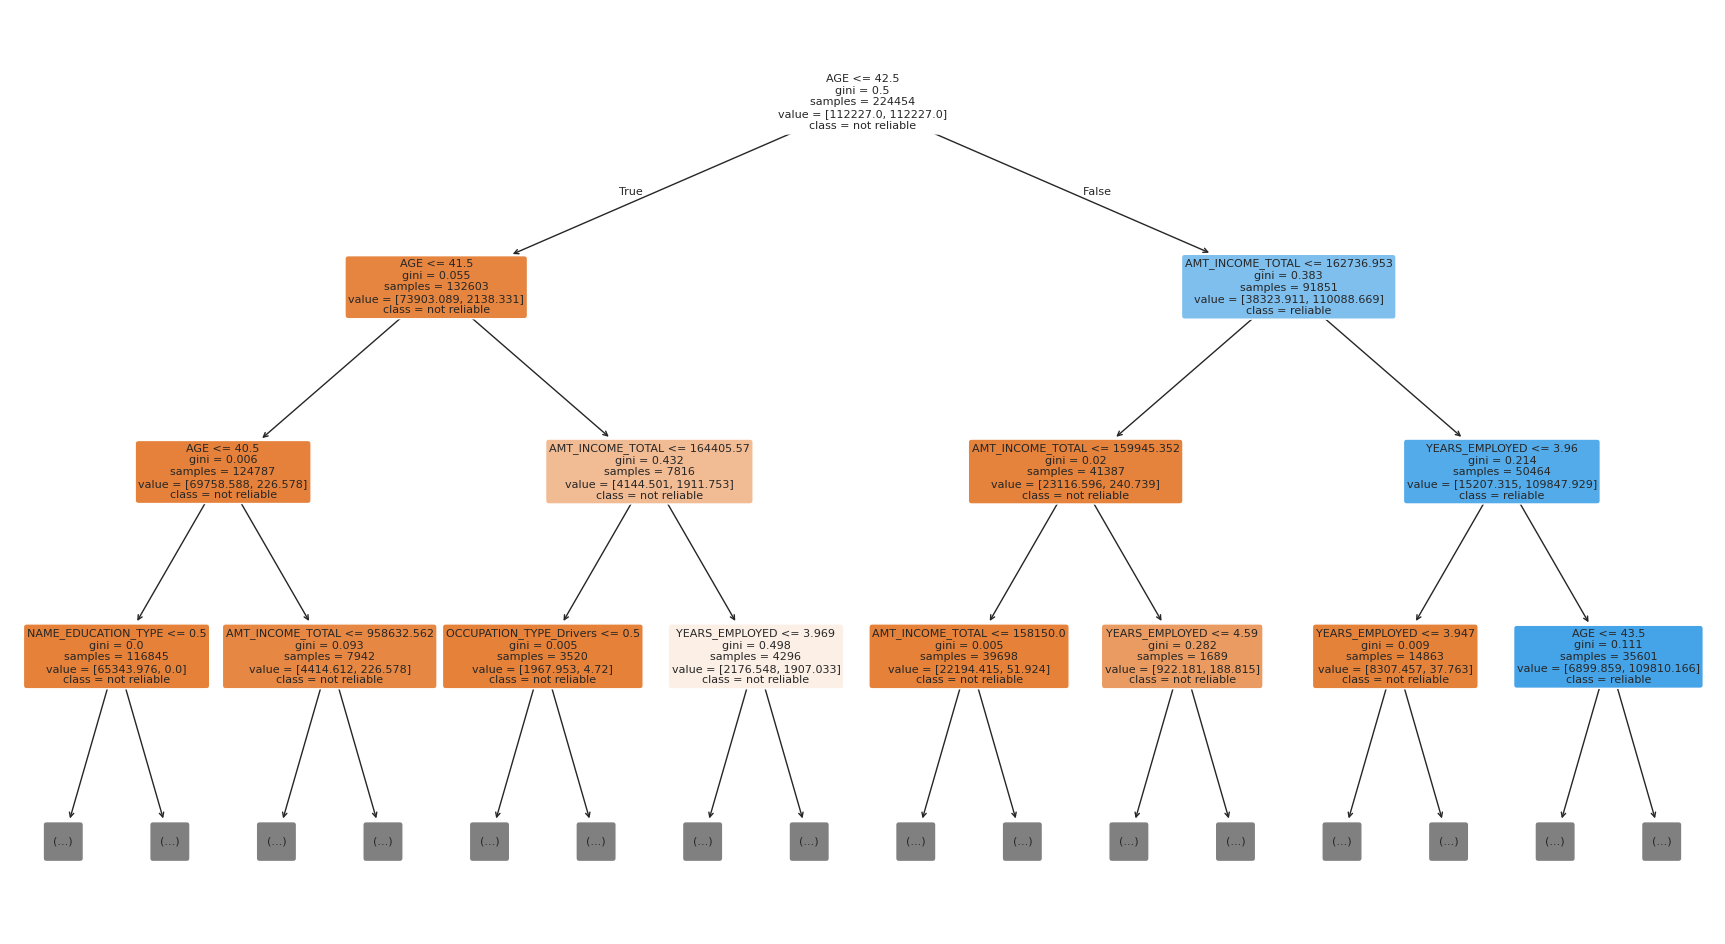

In [ ]:
X_train_original = X_train.copy()
X_test_original = X_test.copy()

X_train_original[to_scale] = ss.inverse_transform(X_train[to_scale])
X_test_original[to_scale] = ss.inverse_transform(X_test[to_scale])

tree_visual = DecisionTreeClassifier(random_state=RANDOM_SEED, class_weight="balanced", max_depth=10)
tree_visual.fit(X_train_original, y_train)

plt.figure(figsize=(22,12))
plot_tree(tree_visual, feature_names=X_train_original.columns, class_names=['not reliable', 'reliable'], filled=True, rounded=True, max_depth=3, fontsize=8)
plt.show()


La visualizzazione dell'albero decisionale conferma come le prime suddivisioni vengano fatte con le variabili dell'età, del reddito annuale e successivamente degli anni di occupazione, come emerso anche con i pesi della regressione logistica.

# Random Forest

Si esegue l'addestramento di un modello di Random Forest in cross-validation per la scelta del numero di alberi da utilizzare

In [ ]:
for n_tree in [1, 2, 3, 5, 10, 20, 50, 100]:
  print(f"Addestramento di una foresta con {n_tree} alberi...")
  forest = RandomForestClassifier(n_tree, random_state=RANDOM_SEED, class_weight="balanced")
  cv_results_rf, cv_results_mean_rf = cv_analysis(forest, X_train, y_train, var_to_scale=to_scale)
  print(cv_results_mean_rf)

Addestramento di una foresta con 1 alberi...
     Metrica  Train_cv_results  Test_cv_results
0   Accuracy            0.9743           0.9298
1     Recall            0.8749           0.6597
2  Precision            0.8814           0.6716
Addestramento di una foresta con 2 alberi...
     Metrica  Train_cv_results  Test_cv_results
0   Accuracy            0.9728           0.9222
1     Recall            0.7720           0.4849
2  Precision            0.9636           0.6885
Addestramento di una foresta con 3 alberi...
     Metrica  Train_cv_results  Test_cv_results
0   Accuracy            0.9862           0.9339
1     Recall            0.9409           0.6923
2  Precision            0.9297           0.6864
Addestramento di una foresta con 5 alberi...
     Metrica  Train_cv_results  Test_cv_results
0   Accuracy            0.9910           0.9353
1     Recall            0.9660           0.7076
2  Precision            0.9503           0.6900
Addestramento di una foresta con 10 alberi...
     M

Bilanciando tra tempo di esecuzione e performance sui test set in cross-validation scegliamo un modello di Random Forest con 50 alberi.  
Anche in questo caso però, come con l'albero decisionale, si osserva la presenza di un forte overfitting soprattutto per le metriche di recall e precision. Si prova quindi a riaddestrare il modello inserendo il parametro max_depth

In [ ]:
rf = RandomForestClassifier(50, random_state=RANDOM_SEED, class_weight="balanced", max_depth=10)
cv_results_rf, cv_results_mean_rf = cv_analysis(rf, X_train, y_train, var_to_scale=to_scale)
cv_results_mean_rf

,Metrica,Train_cv_results,Test_cv_results
0,Accuracy,0.9407,0.9397
1,Recall,0.9940,0.9883
2,Precision,0.6420,0.6391


L'overfitting ora risulta praticamente assente, inoltre la recall è notevolmente migliorata, passando da 0.73 a 0.99, mantenendo la precision a 0.64.
Si addestra dunque l'intero train set con questo modello.

In [ ]:
rf = RandomForestClassifier(50, random_state=RANDOM_SEED, class_weight="balanced", max_depth=10)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
y_pred_train = rf.predict(X_train)

y_proba_rf_train = rf.predict_proba(X_train)[:, 1]
y_proba_rf_test = rf.predict_proba(X_test)[:, 1]

print("TRAIN Random Forest Classification Report:\n", classification_report(y_train, y_pred_train))
print("TEST Random Forest Classification Report:\n", classification_report(y_test, y_pred_rf))

TRAIN Random Forest Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.93      0.97    200679
           1       0.64      0.99      0.78     23775

    accuracy                           0.94    224454
   macro avg       0.82      0.96      0.87    224454
weighted avg       0.96      0.94      0.95    224454

TEST Random Forest Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.93      0.96     50170
           1       0.63      0.99      0.77      5944

    accuracy                           0.94     56114
   macro avg       0.81      0.96      0.87     56114
weighted avg       0.96      0.94      0.94     56114



Si confermano le performance ottenute in cross-validation.

# Confronto tra i modelli e conclusioni

Confrontiamo i modelli con le curve ROC, le matrici di confusione, e i valori delle performances sul test set

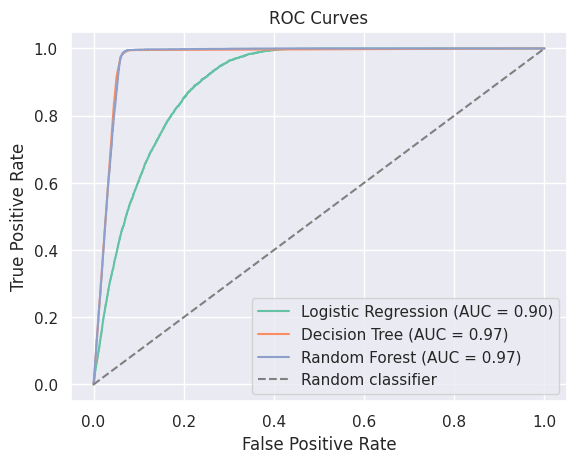

In [ ]:
#ROC curves

fpr_lr, tpr_lr, _ = roc_curve(y_test, y_proba_lr_test)
fpr_tree, tpr_tree, _ = roc_curve(y_test, y_proba_tree_test)
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_proba_rf_test)

auc_lr = roc_auc_score(y_test, y_proba_lr_test)
auc_tree = roc_auc_score(y_test, y_proba_tree_test)
auc_rf = roc_auc_score(y_test, y_proba_rf_test)

plt.plot(fpr_lr, tpr_lr, label=f'Logistic Regression (AUC = {auc_lr:.2f})')
plt.plot(fpr_tree, tpr_tree, label=f'Decision Tree (AUC = {auc_tree:.2f})')
plt.plot(fpr_rf, tpr_rf, label=f'Random Forest (AUC = {auc_rf:.2f})')
plt.title('ROC Curves')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Random classifier')
plt.legend()
plt.show()

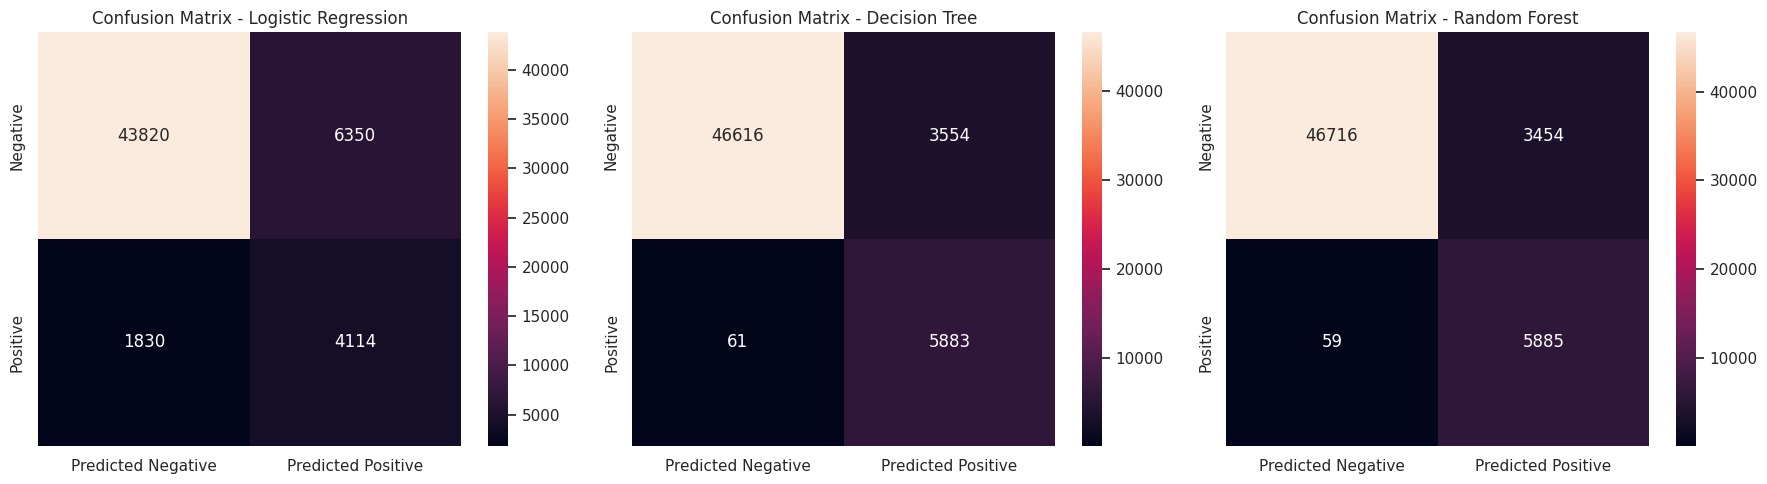

In [ ]:
#confusion matrix

plt.figure(figsize=(18,5))

plt.subplot(1,3,1)
plot_confusion_matrix(y_test, y_proba_test_converted_lr)
plt.title("Confusion Matrix - Logistic Regression")

plt.subplot(1,3,2)
plot_confusion_matrix(y_test, y_pred_tree)
plt.title("Confusion Matrix - Decision Tree")

plt.subplot(1,3,3)
plot_confusion_matrix(y_test, y_pred_rf)
plt.title("Confusion Matrix - Random Forest")

plt.tight_layout()
plt.show()

In [ ]:
#models performances

accuracy_models = [accuracy_score(y_test, y_proba_test_converted_lr), accuracy_score(y_test, y_pred_tree), accuracy_score(y_test, y_pred_rf)]
recall_models = [recall_score(y_test, y_proba_test_converted_lr), recall_score(y_test, y_pred_tree), recall_score(y_test, y_pred_rf)]
precision_models = [precision_score(y_test, y_proba_test_converted_lr), precision_score(y_test, y_pred_tree), precision_score(y_test, y_pred_rf)]
f1_models = [f1_score(y_test, y_proba_test_converted_lr), f1_score(y_test, y_pred_tree), f1_score(y_test, y_pred_rf)]
model_names = ['Logistic Regression', 'Decision Tree', 'Random Forest']


performance_models = pd.DataFrame({'Model': model_names,
                                   'Accuracy': accuracy_models,
                                    'Precision': precision_models,
                                    'Recall': recall_models,
                                    'f1_score': f1_models})
round(performance_models.sort_values('f1_score', ascending=False), 2)

,Model,Accuracy,Precision,Recall,f1_score
2,Random Forest,0.94,0.63,0.99,0.77
1,Decision Tree,0.94,0.62,0.99,0.76
0,Logistic Regression,0.85,0.39,0.69,0.50


Si può osservare come i modelli migliori siano l'albero decisionale e la random forest, con performance molto simili tra loro.  
Entrambi infatti danno nelle curva ROC un'AUC di 0.97, hanno l'f1-score maggiore, bilanciando tra recall e precision, e in particolare una recall di 0.99. Inoltre, rispetto alla regressione logistica, aumentano la precisione da 0.39 a 0.63, andando a diminuire notevolmente il rischio di falsi positivi del modello. Anche dalle matrici di confusione si può infatti osservare un notevole decremento sia di falsi positivi sia di falsi negativi.  
Questo è importante in questo contesto perchè consente di minimizzare il rischio di identificare come soggetto affidabile qualcuno che in reatà non lo è, ma allo stesso tempo consente di non perdere persone che invece hanno affidabilità creditizia e quindi potenziali clienti della banca.

Avendo i due modelli (random forest e albero decisionale) risultati molto simili, si decide di utilizzare l'albero decisionale per mantenere una maggiore interpretabilità atraverso la visualizzazione dell'albero stesso.